# 01 — EDA

Датасет: UCI Default of Credit Card Clients (Taiwan, 30k клиентов).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import settings
from src.data import load_raw
from src.preprocessing import clean, feature_engineering

sns.set_theme(style='whitegrid')
settings.images_dir.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 40)

## Загрузка и обзор

In [2]:
df_raw = load_raw()
print(df_raw.shape)
df_raw.head()

(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         30000 non-null  int64  
 1   LIMIT_BAL  30000 non-null  float64
 2   SEX        30000 non-null  int64  
 3   EDUCATION  30000 non-null  int64  
 4   MARRIAGE   30000 non-null  int64  
 5   AGE        30000 non-null  int64  
 6   PAY_1      30000 non-null  int64  
 7   PAY_2      30000 non-null  int64  
 8   PAY_3      30000 non-null  int64  
 9   PAY_4      30000 non-null  int64  
 10  PAY_5      30000 non-null  int64  
 11  PAY_6      30000 non-null  int64  
 12  BILL_AMT1  30000 non-null  float64
 13  BILL_AMT2  30000 non-null  float64
 14  BILL_AMT3  30000 non-null  float64
 15  BILL_AMT4  30000 non-null  float64
 16  BILL_AMT5  30000 non-null  float64
 17  BILL_AMT6  30000 non-null  float64
 18  PAY_AMT1   30000 non-null  float64
 19  PAY_AMT2   30000 non-null  float64
 20  PAY_AMT3   30000 

In [4]:
print('Пропуски:', df_raw.isna().sum().sum())
print('Дубликаты полных строк:', df_raw.duplicated().sum())
print('Дубликаты по ID:', df_raw['ID'].duplicated().sum())

Пропуски: 0
Дубликаты полных строк: 0
Дубликаты по ID: 0


## Таргет и дисбаланс классов

target
0    0.7788
1    0.2212
Name: proportion, dtype: float64


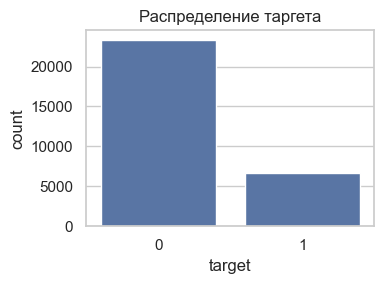

In [5]:
target_counts = df_raw[settings.target_col].value_counts(normalize=True)
print(target_counts)
fig, ax = plt.subplots(figsize=(4, 3))
sns.countplot(x=settings.target_col, data=df_raw, ax=ax)
ax.set_title('Распределение таргета')
fig.tight_layout(); fig.savefig(settings.images_dir / 'target_dist.png', dpi=120); plt.show()

## Недокументированные категории

In [6]:
print('EDUCATION:', sorted(df_raw['EDUCATION'].unique()))
print('MARRIAGE :', sorted(df_raw['MARRIAGE'].unique()))

EDUCATION: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## Очистка и FE

In [7]:
df = feature_engineering(clean(df_raw))
print(df.shape)
df.head()

(29965, 42)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,...,PAY_AMT6,target,UTIL_1,UTIL_2,UTIL_3,UTIL_4,UTIL_5,UTIL_6,PAY_RATIO_1,PAY_RATIO_2,PAY_RATIO_3,PAY_RATIO_4,PAY_RATIO_5,MAX_DELAY,SUM_DELAY,NUM_DELAYS,MEAN_BILL,STD_BILL,MEAN_PAY_AMT,AGE_BUCKET
0,20000.0,2,2,1,24.0,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,...,0.0,1,0.195650,0.155100,0.034450,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2,4,2,1284.000000,1761.633219,114.833333,20-30
1,120000.0,2,2,2,26.0,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,...,2000.0,1,0.022350,0.014375,0.022350,0.027267,0.028792,0.027175,0.000000,0.372856,0.305623,0.289436,0.000000,2,4,2,2846.166667,637.967841,833.333333,20-30
2,90000.0,2,2,2,34.0,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,...,5000.0,0,0.324878,0.155856,0.150656,0.159233,0.166089,0.172767,0.108220,0.110628,0.069779,0.066899,0.064313,0,0,0,16942.166667,6064.518593,1836.333333,30-40
3,50000.0,2,2,1,37.0,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,...,1000.0,0,0.939800,0.964660,0.985820,0.566280,0.579180,0.590940,0.041465,0.040961,0.042382,0.037985,0.036180,0,0,0,38555.666667,10565.793518,1398.000000,30-40
4,50000.0,1,2,1,57.0,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,...,679.0,0,0.172340,0.113400,0.716700,0.418800,0.382920,0.382620,0.352734,1.023608,0.477555,0.470072,0.036015,0,0,0,18223.166667,10668.590074,9841.500000,50+


## Распределения числовых фич

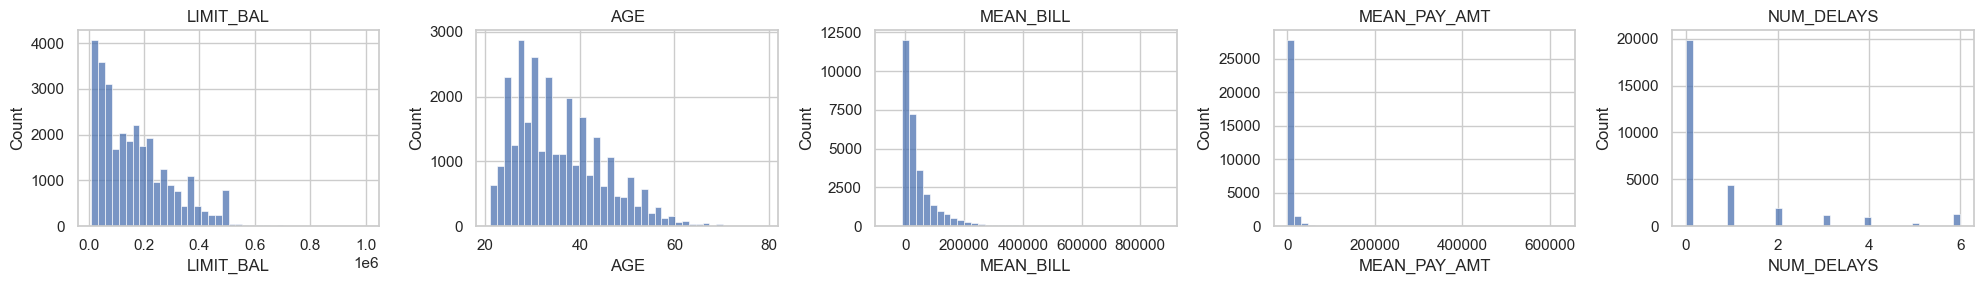

In [8]:
num_cols = ['LIMIT_BAL', 'AGE', 'MEAN_BILL', 'MEAN_PAY_AMT', 'NUM_DELAYS']
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 3))
for ax, c in zip(axes, num_cols):
    sns.histplot(df[c], bins=40, ax=ax, kde=False)
    ax.set_title(c)
fig.tight_layout(); fig.savefig(settings.images_dir / 'num_hists.png', dpi=120); plt.show()

## Корреляционная матрица

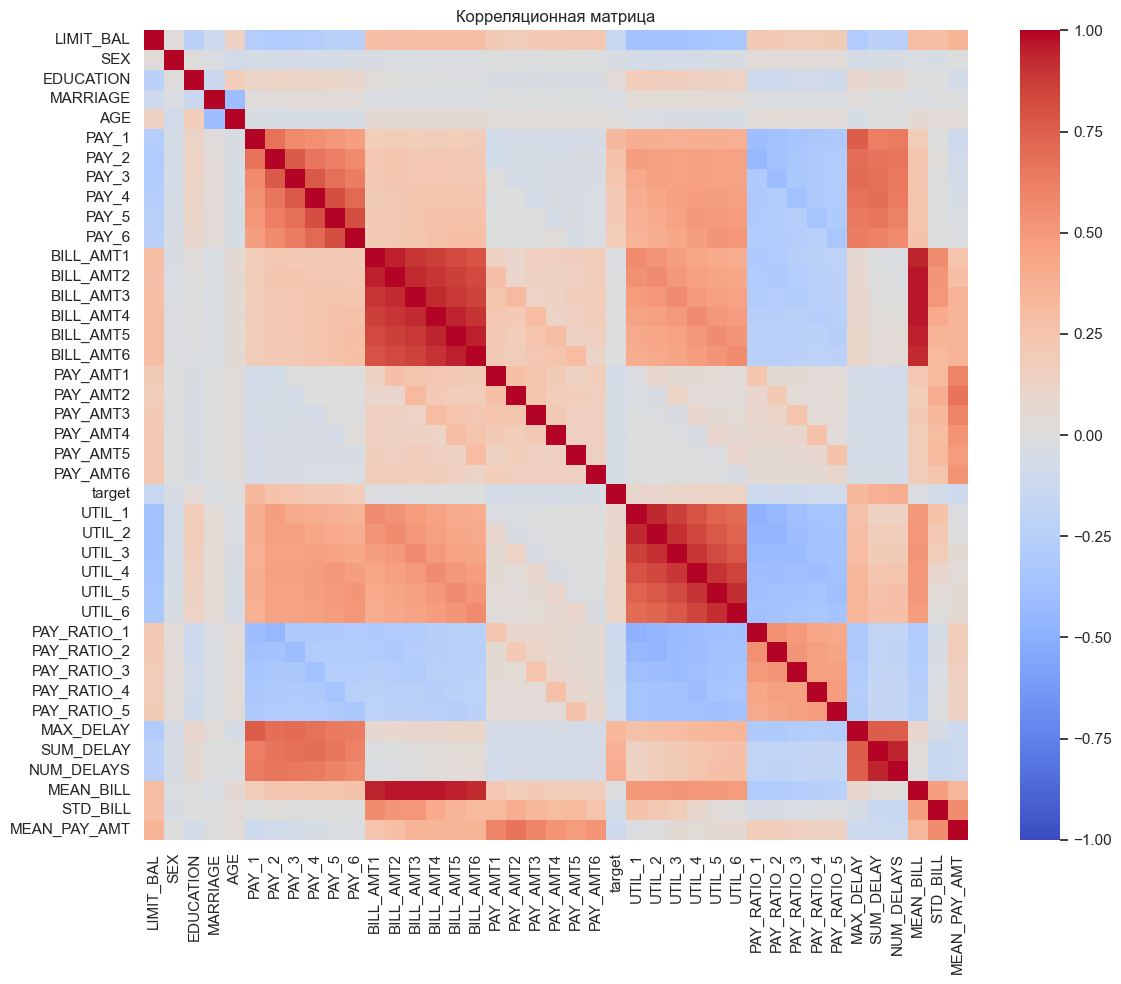

In [9]:
num_df = df.select_dtypes(include='number')
corr = num_df.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Корреляционная матрица'); fig.tight_layout()
fig.savefig(settings.images_dir / 'corr.png', dpi=120); plt.show()

## Дефолт vs статус платежа PAY_1

PAY_1
-2    0.132364
-1    0.167899
 0    0.128113
 1    0.340333
 2    0.691298
 3    0.757764
 4    0.684211
 5    0.500000
 6    0.545455
 7    0.777778
 8    0.578947
Name: target, dtype: float64


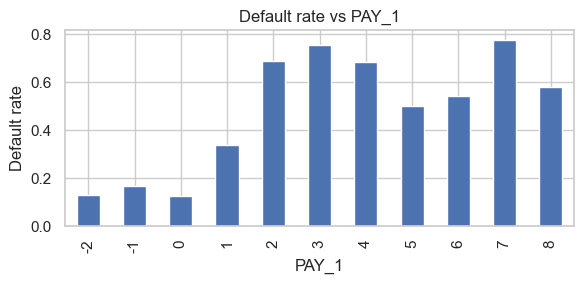

In [10]:
rate = df.groupby('PAY_1')[settings.target_col].mean().sort_index()
print(rate)
fig, ax = plt.subplots(figsize=(6, 3))
rate.plot(kind='bar', ax=ax); ax.set_ylabel('Default rate'); ax.set_title('Default rate vs PAY_1')
fig.tight_layout(); fig.savefig(settings.images_dir / 'default_vs_pay1.png', dpi=120); plt.show()

## Дефолт vs LIMIT_BAL и AGE_BUCKET

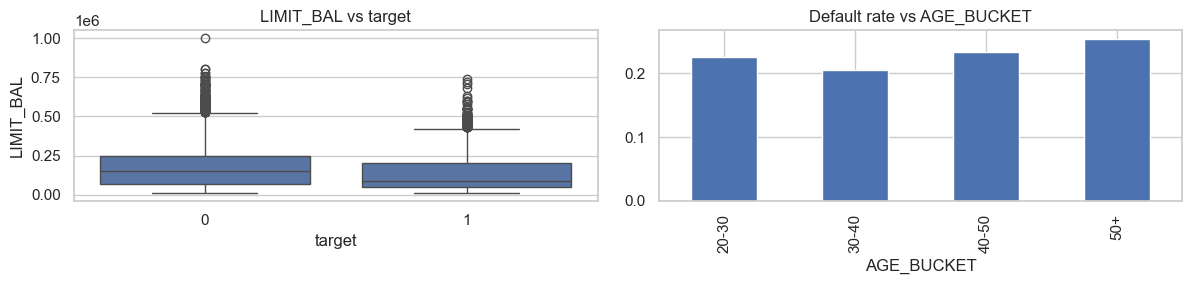

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
sns.boxplot(x=settings.target_col, y='LIMIT_BAL', data=df, ax=axes[0]); axes[0].set_title('LIMIT_BAL vs target')
age_rate = df.groupby('AGE_BUCKET')[settings.target_col].mean().reindex(['20-30','30-40','40-50','50+'])
age_rate.plot(kind='bar', ax=axes[1]); axes[1].set_title('Default rate vs AGE_BUCKET')
fig.tight_layout(); fig.savefig(settings.images_dir / 'limit_age.png', dpi=120); plt.show()

## Выбросы (IQR)

In [12]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).sum()

for c in ['LIMIT_BAL', 'MEAN_BILL', 'MEAN_PAY_AMT']:
    print(c, 'outliers:', iqr_outliers(df[c]))

LIMIT_BAL outliers: 167
MEAN_BILL outliers: 2572
MEAN_PAY_AMT outliers: 2890


## Выводы

- Нет пропусков и дубликатов.
- Дисбаланс ~78/22% → в качестве основной метрики используем ROC-AUC.
- Статус платежа PAY_1 — самый сильный ранний признак дефолта: чем больше задержка, тем выше доля дефолта.
- Клиенты с меньшим кредитным лимитом чаще уходят в дефолт.
- Выбросы в денежных фичах присутствуют, но в этой задаче несут сигнал (высокие траты/платежи) — не обрезаем, используем StandardScaler и при необходимости робастные модели.